In [33]:
#!/usr/bin/env python3
# evaluate.py – AR(168 h) for Multi-head TFM   2025-06-05 rev5

import os, json, pickle, re, gc, numpy as np, pandas as pd, matplotlib.pyplot as plt, torch
from tqdm.auto import tqdm
from sklearn.metrics import brier_score_loss

# ─── User Setting ───
MODEL_DIR  = "models/20250603_165025"
CSV_PATH   = "data.csv"
START_DATE = "2025-01-01 00:00:00"
END_DATE   = "2025-01-02 01:00:00"
HISTORY    = 24
HORIZON    = 24                # 1 day
THR        = 0.30
TARGET_COLS = ["466920氣溫(℃)", "466920降水量(mm)"]
name_map = {"466920氣溫(℃)": "Temp_466920 (°C)",
            "466920降水量(mm)": "Rain_466920 (mm)"}
DBG_FILE   = os.path.join(MODEL_DIR, "log_eval.jsonl")  # 每行一筆 JSON
# ────────────────────

In [34]:
# 1) artefacts ---------------------------------------------------------------
with open(os.path.join(MODEL_DIR, "config.json")) as f:
    cfg = json.load(f)
with open(os.path.join(MODEL_DIR, "scaler.pkl"), "rb") as f:
    scaler = pickle.load(f)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from train import MultiHeadTFM        # 若是 TwoHead，請替換
model = MultiHeadTFM(**cfg).to(DEVICE)
model.load_state_dict(torch.load(os.path.join(MODEL_DIR, "best.pt"),
                                 map_location=DEVICE))
model.eval(); torch.set_grad_enabled(False)

idxs         = cfg["idxs"]
precip_idx   = cfg["idxs"]["precip"]
feat_dim     = cfg["input_dim"]

# 2) dataframe & ETL ---------------------------------------------------------
df = pd.read_csv(CSV_PATH)
df.rename(columns={df.columns[0]: "Datetime"}, inplace=True)
df["Datetime"] = pd.to_datetime(df["Datetime"])
df.sort_values("Datetime", inplace=True); df.reset_index(drop=True, inplace=True)
df["tod"]   = df["Datetime"].dt.hour + df["Datetime"].dt.minute/60
df["month"] = df["Datetime"].dt.month

feat_cols = [c for c in df.columns if c != "Datetime"]
df[feat_cols] = (df[feat_cols]
                 .mask(df[feat_cols] <= -99, np.nan)
                 .interpolate(limit_direction="both"))

all_std = scaler.transform(df[feat_cols]).astype(np.float32)
mu, sig = scaler.mean_.astype(np.float32), scaler.scale_.astype(np.float32)

mask_eval = (df["Datetime"] >= START_DATE) & (df["Datetime"] <= END_DATE)
idx_eval  = np.where(mask_eval.values)[0]
N_eval    = len(idx_eval)
print(f"Eval period: {START_DATE} → {END_DATE}   (hrs = {N_eval})")

tgt_idx    = [feat_cols.index(c) for c in TARGET_COLS]
K          = len(TARGET_COLS)
thr_scaled = (0 - mu[precip_idx]) / sig[precip_idx]


Eval period: 2025-01-01 00:00:00 → 2025-01-02 01:00:00   (hrs = 25)


In [35]:
# 3)  buffers ----------------------------------------------------------------
# 每 lead 取累積 mse，最後再 /cnt → RMSE
lead_err2  = np.zeros((HORIZON, K), dtype=np.float64)
lead_cnt   = np.zeros(HORIZON,       dtype=np.int32)

pred_destd = np.full((N_eval, K), np.nan, dtype=np.float32)

# 準備 debug log 檔
log_f = open(DBG_FILE, "w", encoding="utf-8")
def log_json(obj): json.dump(obj, log_f, ensure_ascii=False); log_f.write("\n")

# 4) rolling origin ----------------------------------------------------------
for rel_org, g_org in enumerate(idx_eval[:-HORIZON]):
    win = all_std[g_org-HISTORY+1 : g_org+1].copy()        # shape (H,P)
    for h in range(1, HORIZON+1):                          # lead = 1~H
        # -------- forward --------
        x = torch.tensor(win[-HISTORY:][None], device=DEVICE)
        out = model(x)

        full_std = np.zeros(feat_dim, dtype=np.float32)
        full_std[idxs["temp"]]  = out["temp"].cpu().numpy()[0]
        full_std[idxs["press"]] = out["press"].cpu().numpy()[0]
        full_std[idxs["wind"]]  = out["wind"].cpu().numpy()[0]
        full_std[idxs["other"]] = out["other"].cpu().numpy()[0]

        p_cls = out["p_cls"].cpu().numpy()[0]
        p_amt = out["p_amt"].cpu().numpy()[0]
        full_std[precip_idx] = (p_cls > THR).astype(float) * p_amt

        win = np.vstack([win, full_std])                   # 滾動窗口

        # -------- 資料對齊 --------
        g_idx = g_org + h                                  # global index of pred
        if g_idx not in idx_eval: continue                 # 超出 eval 範圍

        slot   = np.where(idx_eval == g_idx)[0][0]         # 0-based slot
        raw    = full_std[tgt_idx] * sig[tgt_idx] + mu[tgt_idx]
        pred_destd[slot] = raw                             # 覆寫最新投票

        truth_raw = df.iloc[g_idx, :][TARGET_COLS].values.astype(np.float32)

        lead_err2[h-1] += (raw - truth_raw) ** 2
        lead_cnt[h-1]  += 1

        # -------- log --------
        log_json({"timestamp": df.loc[g_idx, "Datetime"].isoformat(),
                  "lead_h": h,
                  "pred_std": full_std[tgt_idx].round(6).tolist(),
                  "pred_raw": raw.round(3).tolist(),
                  "true_raw": truth_raw.round(3).tolist()})

        # -------- Brier --------
        brier_s = brier_score_loss(
            (win[-2, precip_idx] > thr_scaled).astype(int), p_cls)
        brier_n = 1
        log_json({"timestamp": df.loc[g_idx, "Datetime"].isoformat(),
                  "lead_h": h,
                  "brier": round(brier_s / brier_n, 5)})

log_f.close()
print(f"Debug logs saved to {DBG_FILE}")

Debug logs saved to models/20250603_165025\log_eval.jsonl



===== Lead-time RMSE =====
Temp_466920 (°C)      1h: 2.30   24h:11.03
Rain_466920 (mm)      1h: 0.28   24h: 0.78


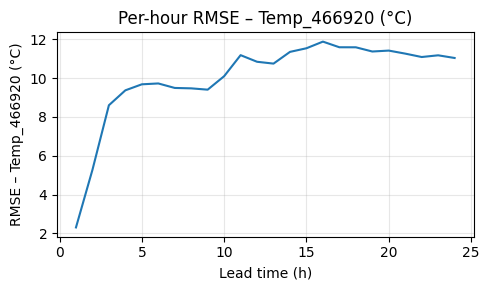

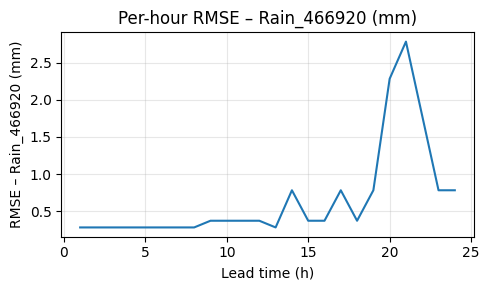

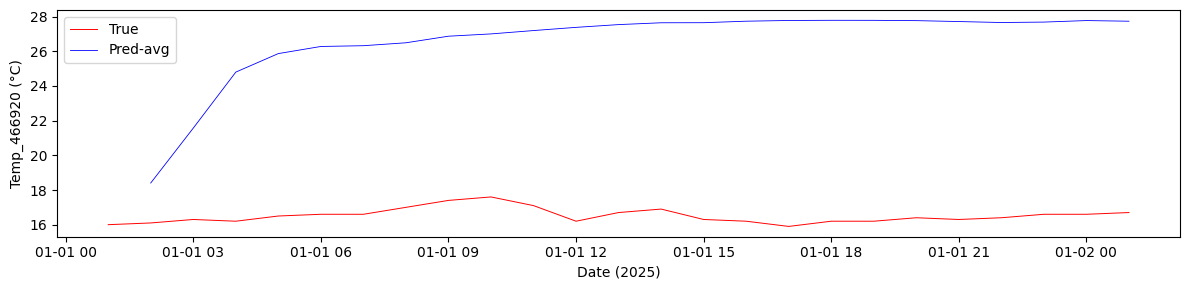

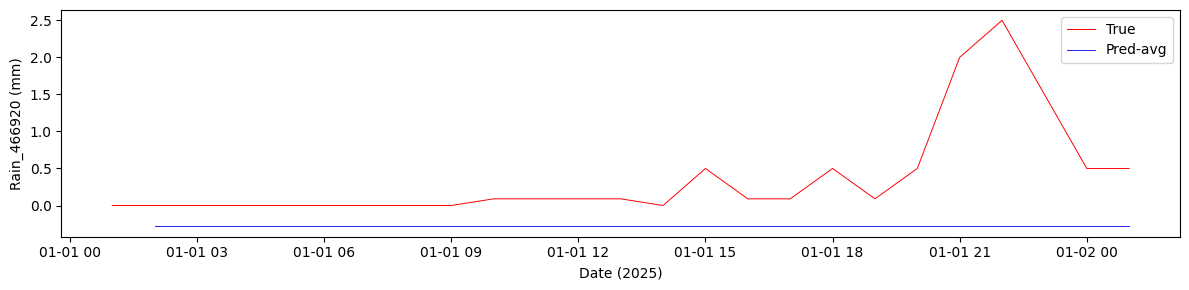

6539

In [36]:

# 5) RMSE --------------------------------------------------------------------
rmse_lead = np.sqrt(lead_err2 / np.where(lead_cnt==0, 1, lead_cnt)[:,None])

print("\n===== Lead-time RMSE =====")
for k,col in enumerate(TARGET_COLS):
    v = rmse_lead[:,k]
    print(f"{name_map.get(col,col):<20s}  1h:{v[0]:5.2f}   "
          f"{HORIZON}h:{v[HORIZON-1]:5.2f}")

# 6) plots -------------------------------------------------------------------
hrs = np.arange(1, HORIZON+1)
for k,col in enumerate(TARGET_COLS):
    lbl = name_map.get(col,col)
    plt.figure(figsize=(5,3))
    plt.plot(hrs, rmse_lead[:,k]); plt.grid(alpha=.3)
    plt.xlabel("Lead time (h)"); plt.ylabel(f"RMSE – {lbl}")
    plt.title(f"Per-hour RMSE – {lbl}")
    plt.tight_layout(); plt.show()

# time-series
dt = df.loc[mask_eval, "Datetime"].values
for k,col in enumerate(TARGET_COLS):
    plt.figure(figsize=(12,3))
    plt.plot(dt, df.loc[mask_eval, col].values, 'r', lw=.7, label="True")
    plt.plot(dt, pred_destd[:,k], 'b', lw=.6, label="Pred-avg")
    plt.ylabel(name_map.get(col,col)); plt.xlabel("Date (2025)")
    plt.legend(); plt.tight_layout(); plt.show()

# 清理 GPU
torch.cuda.empty_cache(); gc.collect()

In [37]:
print(scaler.mean_[tgt_idx])

[23.96458367 -0.28232974]
